In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)
SRC_DIR = PROJECT_ROOT 
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

c:\Users\aless\OneDrive\unimi_projects\data_shapley


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import  load_wine
from src.utils import (
    set_seed, make_synthetic_dataset,
    plot_noise_comparison_curves, plot_shapley_quantiles_by_noise,
    plot_quantile_shapley_clean_vs_noisy_by_noise
)
from src.experiment import run_all_noise_levels

set_seed(42)
np.set_printoptions(precision=4, suppress=True)
RESULTS = Path("../results"); 
RESULTS.mkdir(exist_ok=True)
FIGS = RESULTS / "figures"; 
FIGS.mkdir(exist_ok=True)
NOISE_LEVELS = {"no_noise": 0.0, "low": 0.05, "medium": 0.15, "high": 0.30}


Parametri e dataset di input

In [3]:
CANDIDATE_K   = [1, 3, 5, 7, 9, 12, 14]
FRACTIONS     = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.7]
N_PERMUTATIONS = 100
N_RANDOM_REPEATS = 20
COMPARE_FRACTION = 0.2
SYN_FEATURE_LEN = [4, 16, 32]
SYN_NOISE_TYPE = ['noisy']# 'redundant']
wine = load_wine()

datasets = {
    "wine":    (wine.data, wine.target),
}

for snt in SYN_NOISE_TYPE: 
    for sfl in SYN_FEATURE_LEN: 
        dataset_name = f'syn_{snt[:3]}_{sfl}d'
        X_syn, y_syn = make_synthetic_dataset(
            n_samples=200,
            n_features=sfl,
            informative_dim=3,
            mode=snt,
            noise_level=0.0,
            seed=42,
        )
        datasets[dataset_name] = (X_syn, y_syn)

for name, (X, y) in datasets.items():
    print(f"{name:10s} — {X.shape[0]} campioni, {X.shape[1]} feature, "
          f"{len(np.unique(y))} classi")

all_results = {}

for name, (X, y) in datasets.items():
    print(f"\n{'='*55}\nDATASET: {name}\n{'='*55}")

    #matrice delle distanze precomputata UNA VOLTA per dataset
    #distmat = precompute_distances(X)

    all_results[name] = run_all_noise_levels(
        X, y,
        candidate_k=CANDIDATE_K,
        fractions=FRACTIONS,
        n_permutations=N_PERMUTATIONS,
        n_random_repeats=N_RANDOM_REPEATS,
        seed=42,
        noise_levels=NOISE_LEVELS,
        #distmat=distmat,   
    )

    for level in NOISE_LEVELS:
        res = all_results[name][level]
        print(f"  [{level:6s}] k={res['best_k']}, CV={res['cv_score']:.3f}, "
              f"baseline={res['removal']['acc_baseline'][0]:.3f}", end="")
        if res["detection"]:
            d = res["detection"]
            print(f", noise@bottom20={d['n_noise_in_bottom20']}/{d['n_noise']}")
        else:
            print()


wine       — 178 campioni, 13 feature, 3 classi
syn_noi_4d — 200 campioni, 4 feature, 2 classi
syn_noi_16d — 200 campioni, 16 feature, 2 classi
syn_noi_32d — 200 campioni, 32 feature, 2 classi

DATASET: wine
  [no_noise] k=1, CV=0.725, baseline=0.706
  [low   ] k=14, CV=0.678, baseline=0.765, noise@bottom20=3/5
  [medium] k=9, CV=0.658, baseline=0.765, noise@bottom20=3/16
  [high  ] k=9, CV=0.529, baseline=0.706, noise@bottom20=14/32

DATASET: syn_noi_4d
  [no_noise] k=14, CV=0.910, baseline=0.923
  [low   ] k=14, CV=0.851, baseline=0.897, noise@bottom20=1/6
  [medium] k=12, CV=0.810, baseline=0.872, noise@bottom20=8/18
  [high  ] k=5, CV=0.613, baseline=0.667, noise@bottom20=19/36

DATASET: syn_noi_16d
  [no_noise] k=14, CV=0.826, baseline=0.718
  [low   ] k=9, CV=0.761, baseline=0.692, noise@bottom20=3/6
  [medium] k=12, CV=0.670, baseline=0.718, noise@bottom20=9/18
  [high  ] k=9, CV=0.504, baseline=0.462, noise@bottom20=15/36

DATASET: syn_noi_32d
  [no_noise] k=14, CV=0.751, basel

distribuzioni e curve per dataset (nbf : salvati prima)

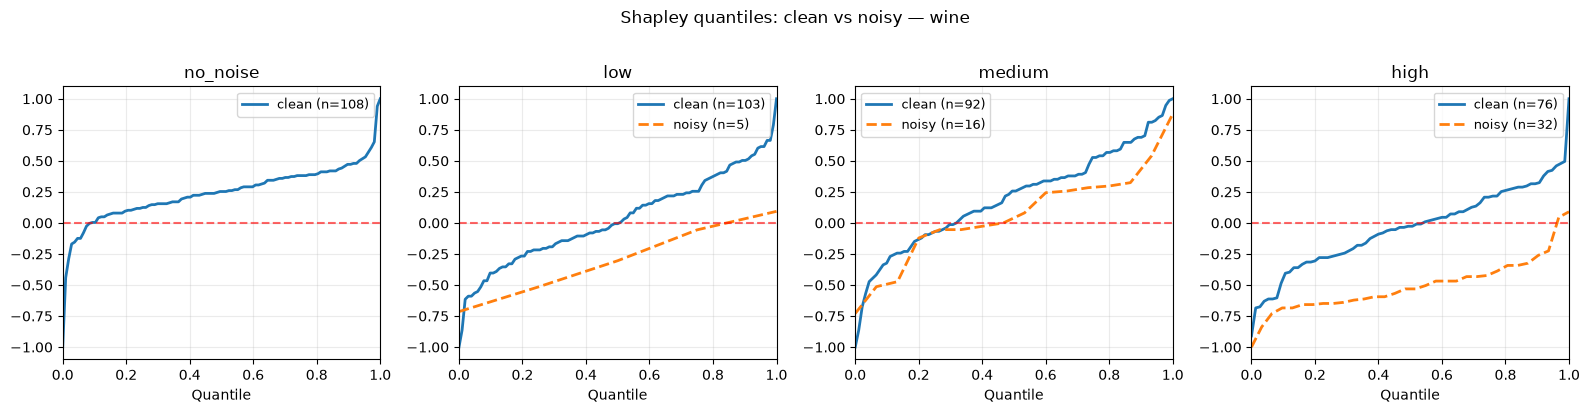

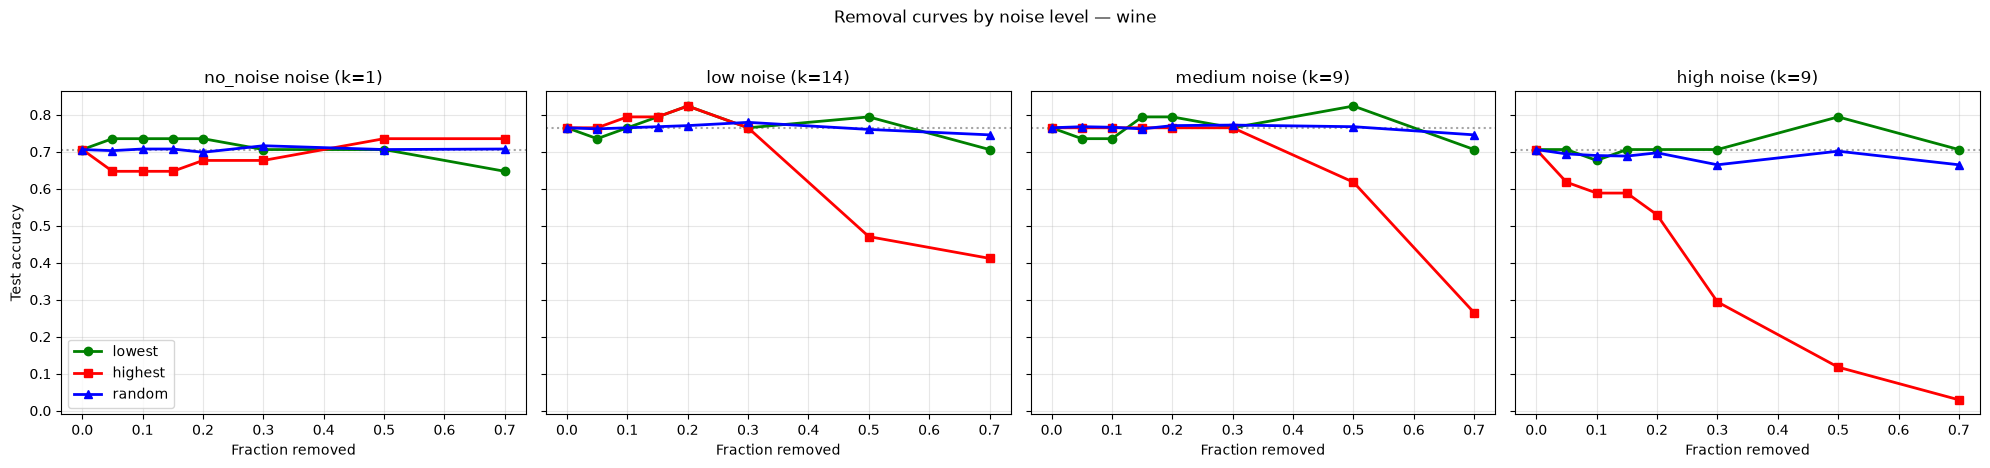

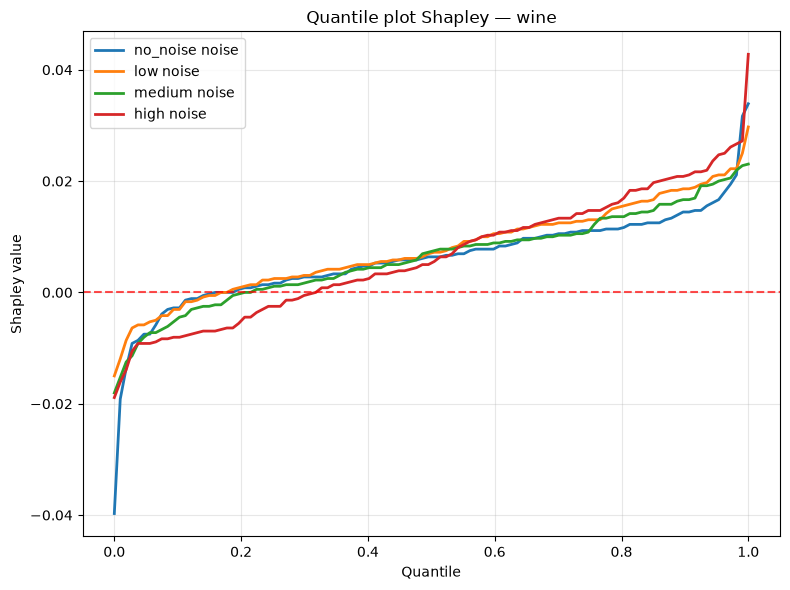

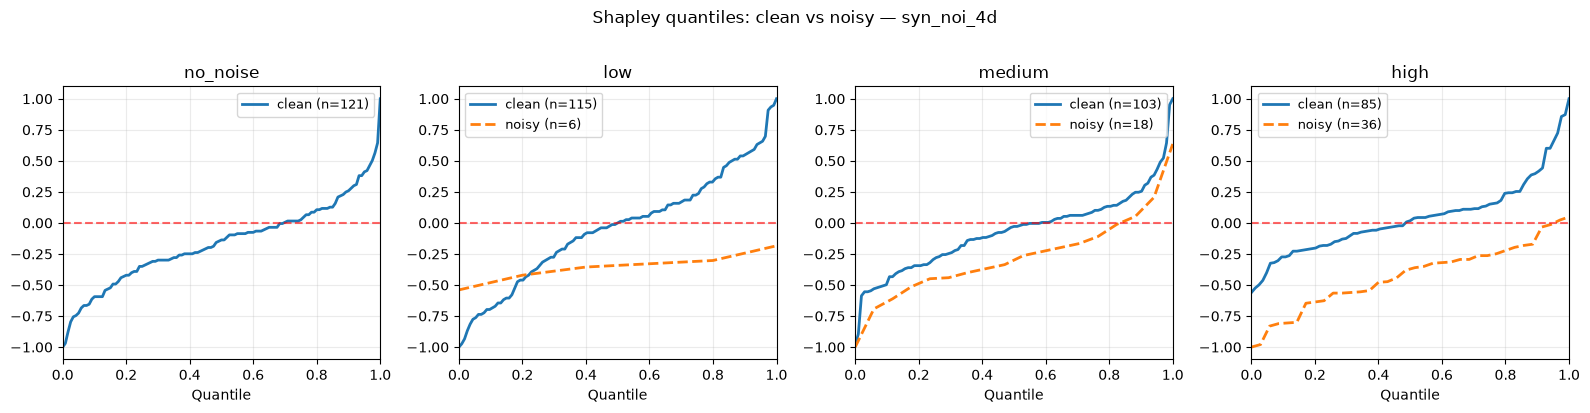

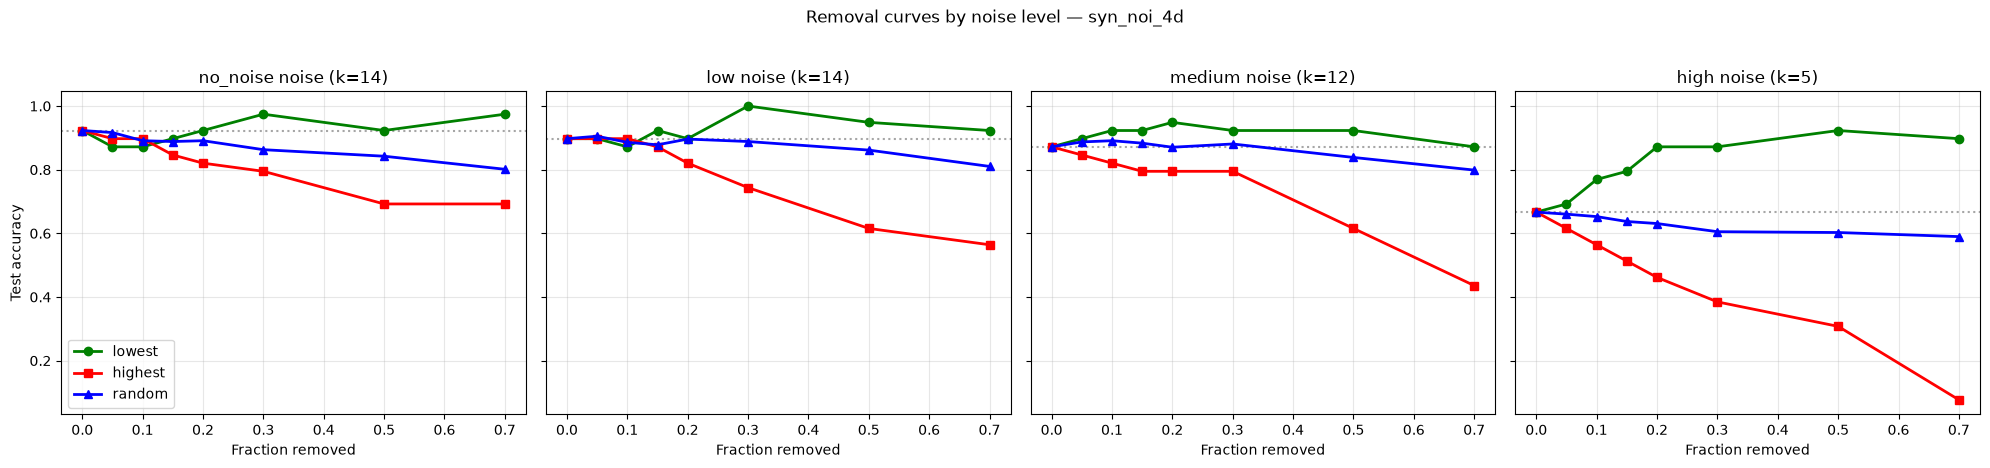

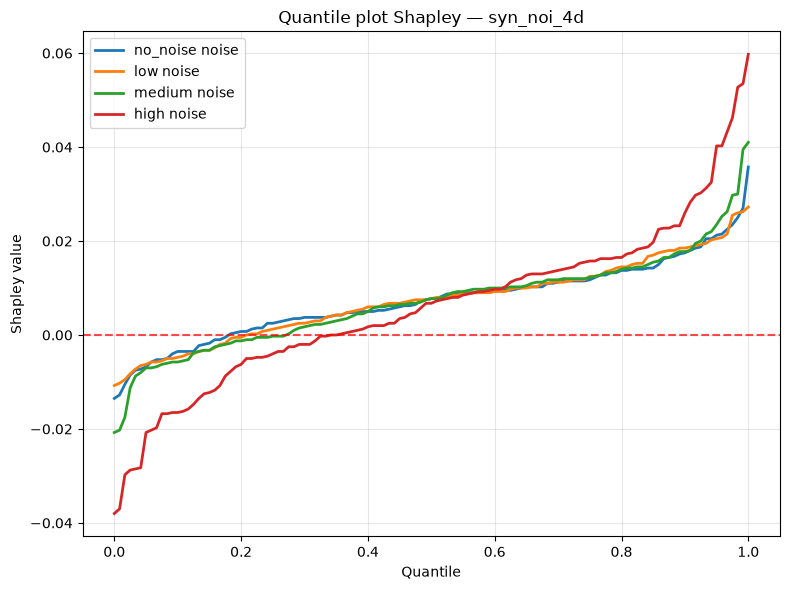

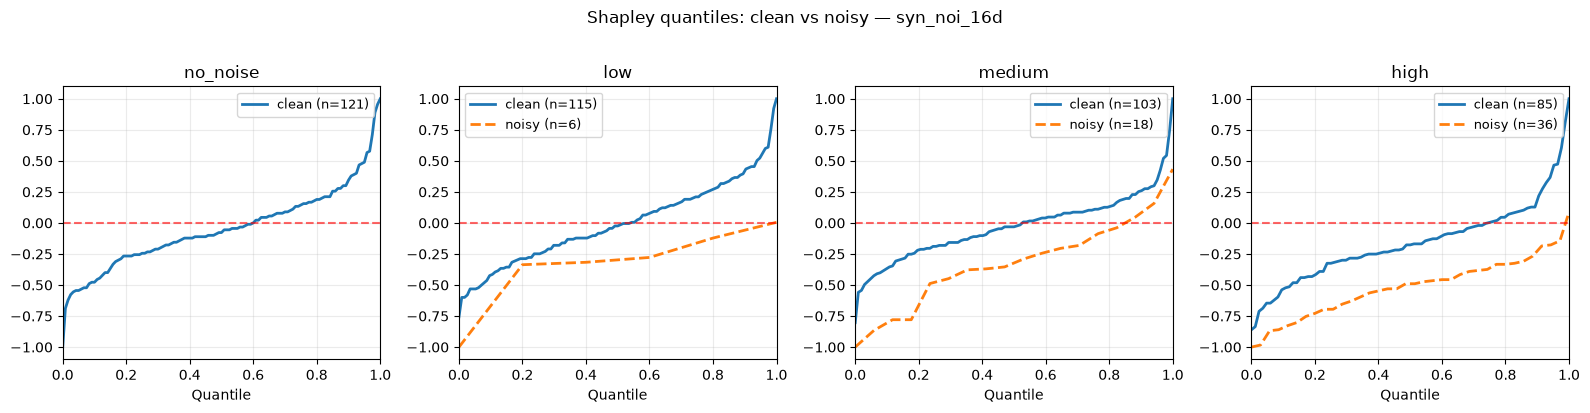

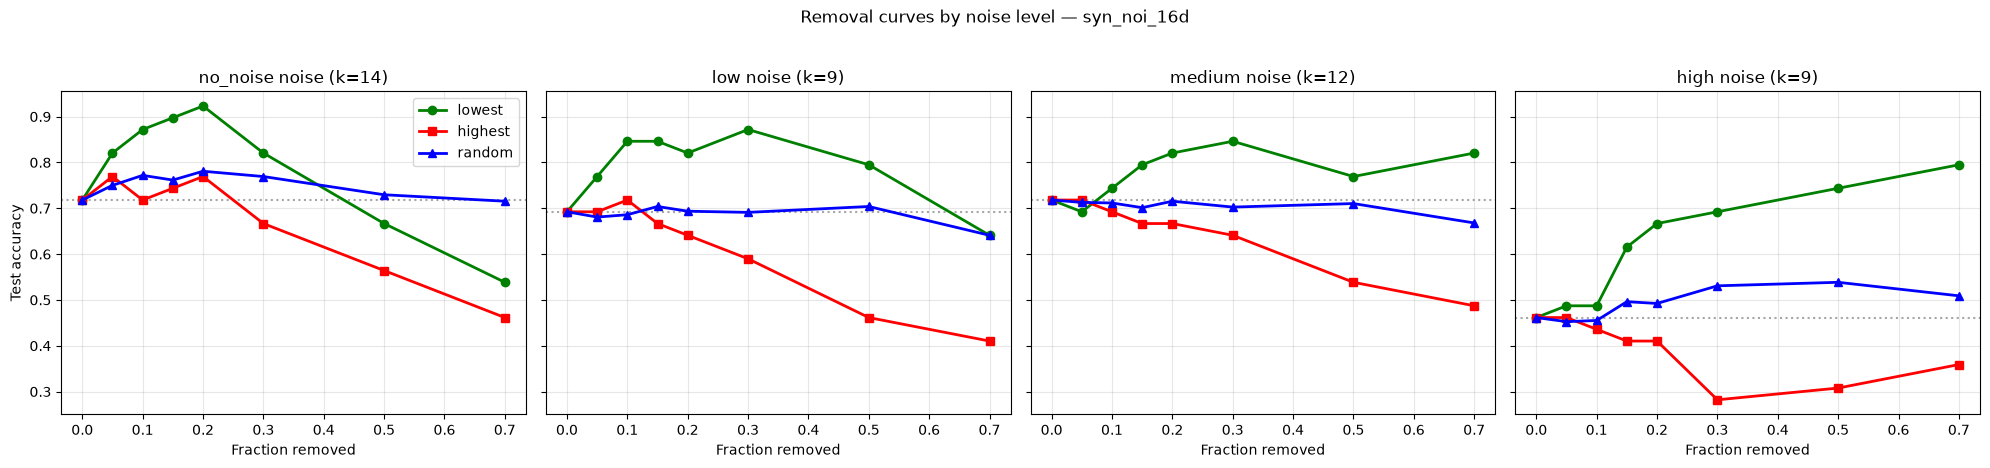

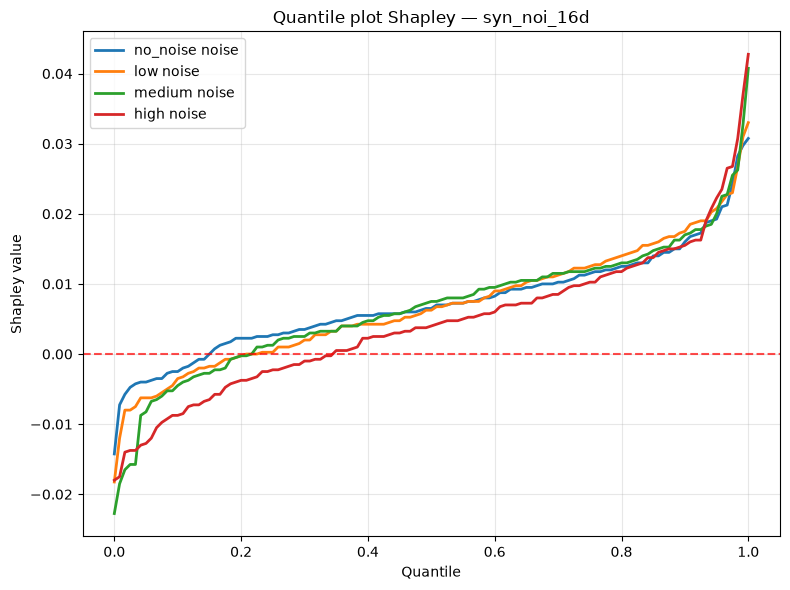

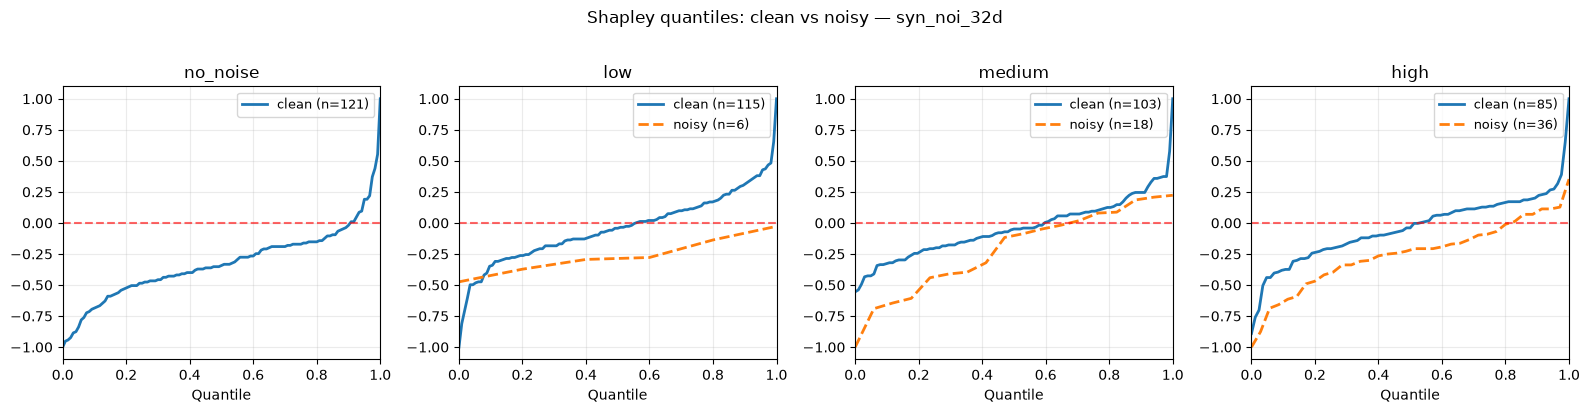

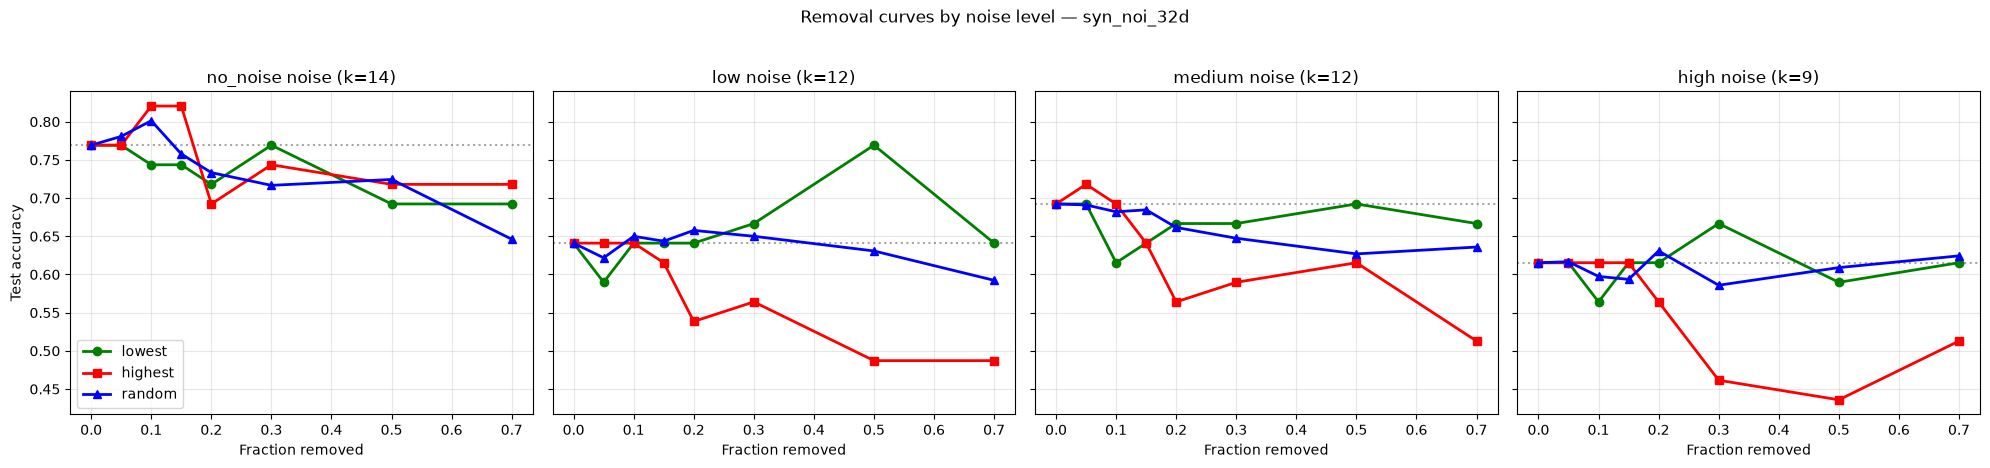

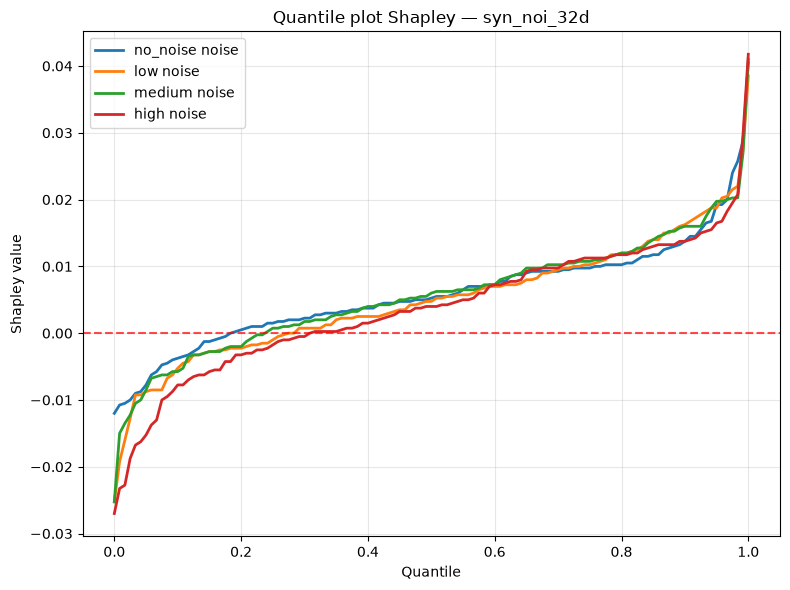

In [4]:
for name in datasets:
    plot_quantile_shapley_clean_vs_noisy_by_noise(all_results,ds_name=name,levels=list(NOISE_LEVELS.keys()),save_path=FIGS)
    plot_noise_comparison_curves(all_results[name],  ds_name=name, levels=list(NOISE_LEVELS.keys()),save_path=FIGS)
    plot_shapley_quantiles_by_noise(all_results,ds_name=name,levels=list(NOISE_LEVELS.keys()),save_path=FIGS)
